In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = {
    'idade': [22, 25, 30, 35, 28, 29, 27, 23, 32, 25],
    'indice_imc': [22.5, 30.1, 45.0, 26.5, 28.0, 35.0, 20.0, 18.0, 23.5, 30.1],
    'micropolicistico': ['Sim', 'Sim', 'Sim', 'Não', 'Sim', 'Sim', 'Sim', 'Não', 'Sim', 'Sim'],
    'tentando_engravidar': ['Sim', 'Sim', 'Não', 'Sim', 'Sim', 'Sim', 'Não', 'Sim', 'Sim', 'Sim'],
    'engravidou': ['Sim', 'Não', 'Não', 'Sim', 'Não', 'Não', 'Não', 'Sim', 'Sim', 'Não']
}
df = pd.DataFrame(data)

In [4]:
le = LabelEncoder()
df['micropolicistico'] = le.fit_transform(df['micropolicistico'])  # Sim=1, Não=0
df['tentando_engravidar'] = le.fit_transform(df['tentando_engravidar'])  # Sim=1, Não=0
df['engravidou'] = le.fit_transform(df['engravidou'])  # Sim=1, Não=0

In [5]:
X = df[['idade', 'indice_imc', 'micropolicistico', 'tentando_engravidar']]
y = df['engravidou']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [7]:
modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [8]:
y_pred = modelo.predict(X_test)


In [10]:
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de classificação:\n", classification_report(y_test, y_pred))

Acurácia: 0.6666666666666666

Relatório de classificação:
               precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


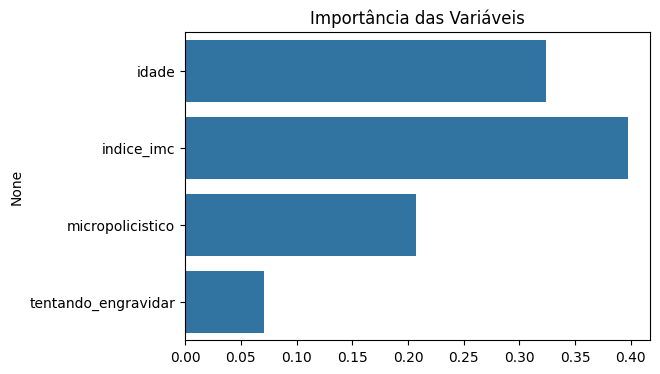

In [9]:
importances = modelo.feature_importances_
features = X.columns
plt.figure(figsize=(6, 4))
sns.barplot(x=importances, y=features)
plt.title('Importância das Variáveis')
plt.show()